# Group Assignment: Go with the flow

Use this notebook to carry out the analysis, inspect the results, and prepare a concise set of handwritten notes. In particular, make sure you complete the goodness-of-fit assessment in Part 4, the dependence analysis in Part 6, and the two raw contingency tables in Part 7 before laptops close.

## Case: Flow velocity of the River Thames

**What is the propagated uncertainty? How fast does the River Thames flow at Kingston?**

You have paired observations of water depth $h$ [m] and flow rate (discharge) $q$ [m$^3$/s] from a measuring station on the River Thames at Kingston, UK. The observations were collected every 15 minutes over one month.

Discharge $q$ is related to mean flow velocity $u$ by

$$q = uS,$$

where $S$ is the cross-sectional area. For this simplified analysis, approximate the cross-section as rectangular with an effective river width of

$$w=95\ \mathrm{m},$$

so that

$$S \approx wh, \qquad u=\frac{q}{wh}=\frac{q}{95h}.$$

Your goals are to:

1. explore and model the marginal distributions of $h$ and $q$;
2. assess the fitted distributions graphically;
3. propagate the fitted distributions to $u$, initially assuming $h$ and $q$ are independent;
4. compare the dependence in the observations with that in the independent simulation;
5. prepare two raw contingency tables from the course questionnaire for the paper-only part of the GA.

The Thames data originate from the UK Department for Environment, Food & Rural Affairs' Data Services platform.


In [117]:
import os
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.rcParams.update({'font.size': 14})

## Part 1. Explore the data


In [118]:
def findfile(fname):
    """Download a MUDE source file only if it is not already in the repository."""
    if not os.path.isfile(fname):
        print(f'Downloading {fname}...')
        urlretrieve(
            'https://github.com/TUDelft-MUDE/source-files/raw/main/file/GA1.4/' + fname,
            fname
        )

findfile('dataset_thames.csv')
h, q = np.genfromtxt('dataset_thames.csv', delimiter=',', unpack=True, skip_header=True)


>**Task 1 — explore the observations:**
>
>
>Plot the observations of $h$ and $q$ and summarize each variable numerically. At minimum, determine its mean, standard deviation, range, and skewness.
>
>Compare the **relative variability** of the two variables using the coefficient of variation,
>
>$$CV = \frac{s}{\bar{x}}.$$
>
>What features of the two empirical distributions would matter when selecting a parametric model later?
>


For h = min: 3.338, mean: 3.402, std: 0.023, skew: 0.692, range: 0.145
For q = min: 0.784, mean: 8.657, std: 2.591, skew: 1.145, range: 18.796
coefficient of variation for h: 0.00682, for q: 0.29935


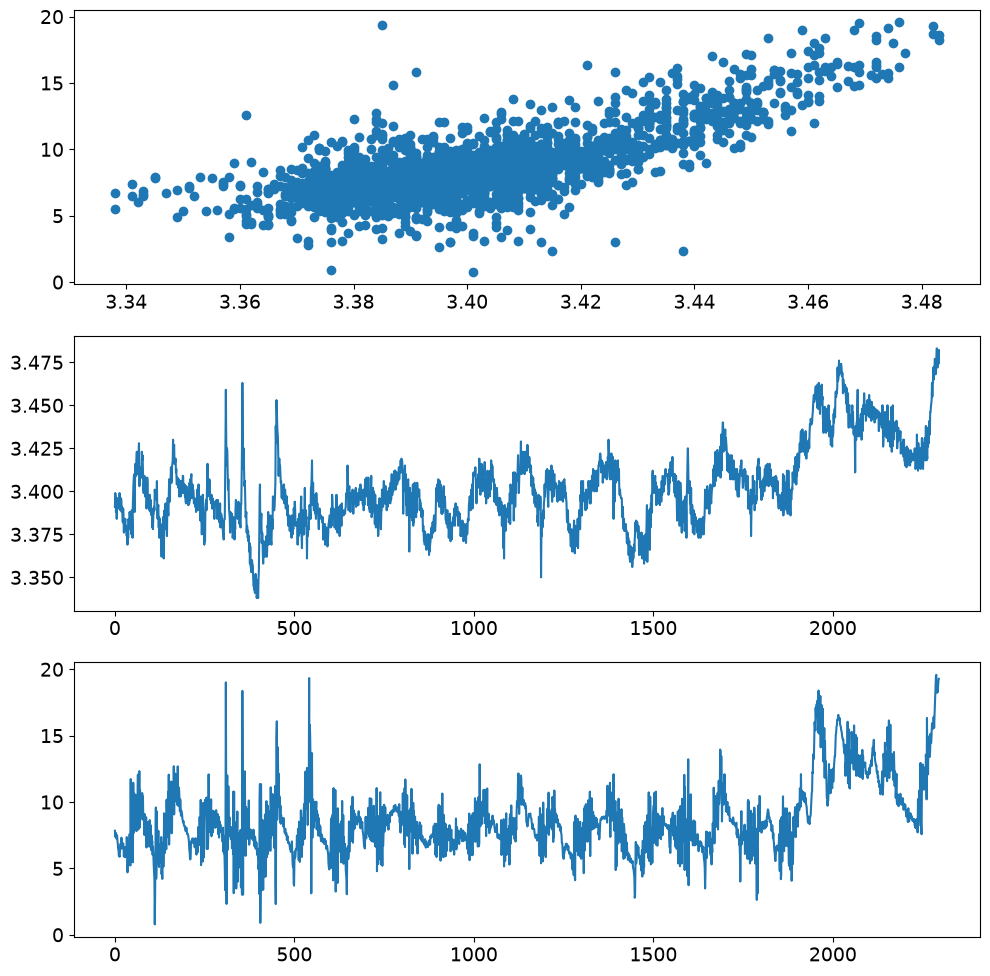

In [130]:
h_min = h.min()
h_max = h.max()
h_mean = h.mean()
h_std = h.std()
h_skew = stats.skew(h)
h_range = h_max - h_min
h_CV = h_std / h_mean

q_min = q.min()
q_max = q.max()
q_mean = q.mean()
q_std = q.std()
q_skew = stats.skew(q)
q_range = q_max - q_min
q_CV = q_std / q_mean

print(f"For h = min: {h_min:.3f}, mean: {h_mean:.3f}, std: {h_std:.3f}, skew: {h_skew:.3f}, range: {h_range:.3f}")
print(f"For q = min: {q_min:.3f}, mean: {q_mean:.3f}, std: {q_std:.3f}, skew: {q_skew:.3f}, range: {q_range:.3f}")
print(f"coefficient of variation for h: {h_CV:.5f}, for q: {q_CV:.5f}")

plt.figure(figsize=(10,10))
plt.subplot(311)
plt.scatter(h,q)

plt.subplot(312)
plt.plot(h)

plt.subplot(313)
plt.plot(q)
plt.tight_layout()

## Part 2. Empirical distribution functions

The function below is given — you used the same idea in the workshop.


In [120]:
def ecdf(var):
    x = np.sort(var)
    n = x.size
    y = np.arange(1, n + 1) / (n + 1)
    return [y, x]


>**Task 2 — visualize the empirical distributions:**
>
>
>For both $h$ and $q$, make a **density-normalized histogram** and an **empirical CDF**. Use the plots together with your statistics from Task 1 to characterize the shape of each distribution.
>


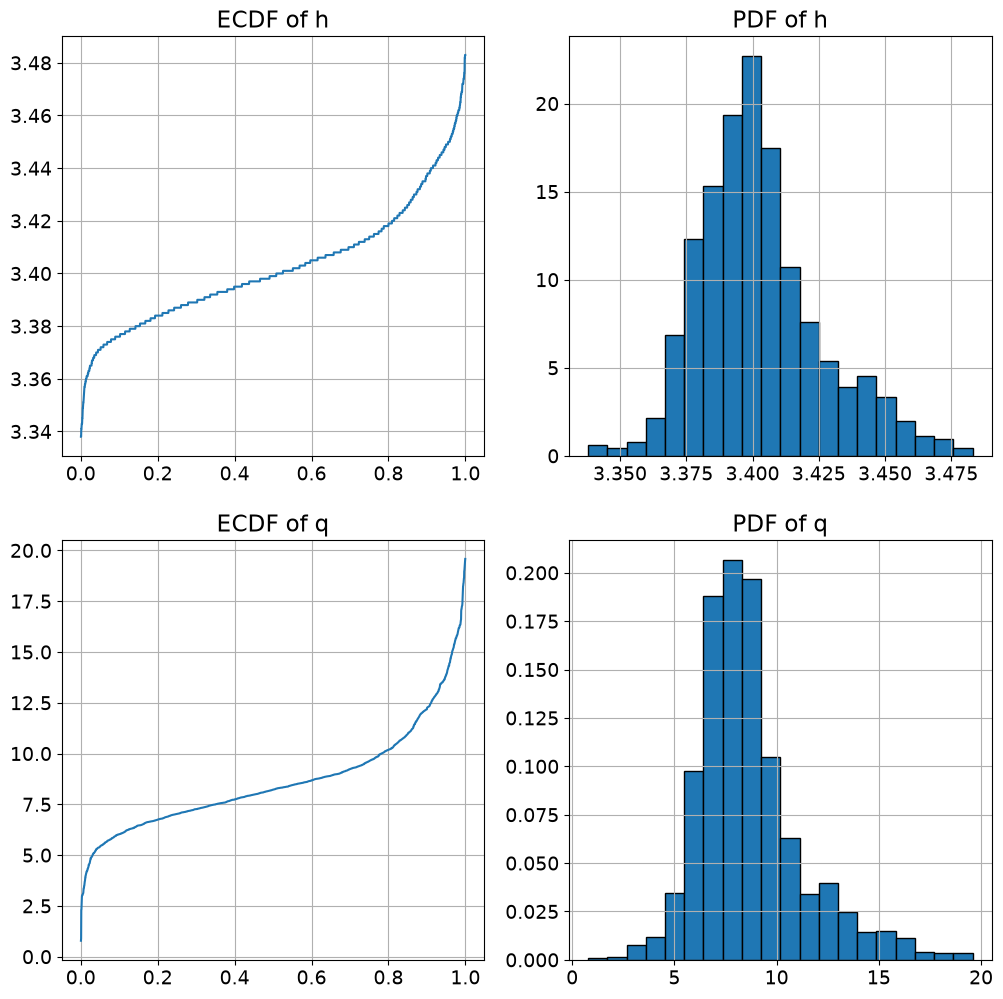

In [131]:
p_h, x_h = ecdf(h)
p_q, x_q = ecdf(q)

plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.plot(p_h, x_h)
plt.grid()
plt.title("ECDF of h")

plt.subplot(223)
plt.plot(p_q, x_q)
plt.grid()
plt.title("ECDF of q")

plt.subplot(222)
plt.hist(h, bins=20, density=True, edgecolor='black')
plt.grid()
plt.title("PDF of h")

plt.subplot(224)
plt.hist(q, bins=20, density=True, edgecolor='black')
plt.grid()
plt.title("PDF of q");


## Part 3. Fitting a distribution


>**Task 3 — choose and fit parametric models:**
>
>
>Based on Tasks 1 and 2, choose one candidate distribution for each variable:
>
>- for $h$: **Uniform** or **Lognormal**;
>- for $q$: **Gaussian** or **Gumbel**.
>
>Briefly justify each choice, then fit the selected distributions using `scipy.stats` (MLE). Store the fitted parameters as `params_h` and `params_q`.
>


*Your justification here.*


In [134]:
params_h = stats.lognorm.fit(h)
params_q = stats.gumbel_r.fit(q)

print(f"shape: {params_h[0]}, loc: {params_h[1]}, scale: {params_h[2]}")
print(f"location: {params_q[0]}, scale: {params_q[1]}")
print(*params_h)

shape: 0.1921240552497483, loc: 3.2835837648625814, scale: 0.11666407834872643
location: 7.498689888072776, scale: 2.1212576118774233
0.1921240552497483 3.2835837648625814 0.11666407834872643


## Part 4. Assessing goodness of fit


A fitted distribution is a model, not a guarantee that the observations actually follow it. Use a graphical goodness-of-fit check to compare each fitted distribution with the empirical distribution. Inspect the agreement across the observed range, paying particular attention to regions where the curves diverge. No formal hypothesis test is required here.


>**Task 4 — graphical goodness of fit:**
>
>
>For both $h$ and $q$, compare the empirical **exceedance probability** with the fitted model on a logarithmic probability axis.
>
>For each variable, decide whether the fitted distribution represents the observations reasonably well. While the plots are visible, write a short note by hand recording your **overall judgement and the main evidence from the plot that supports it**. Make a qualitative sketch of these plots for later.
>


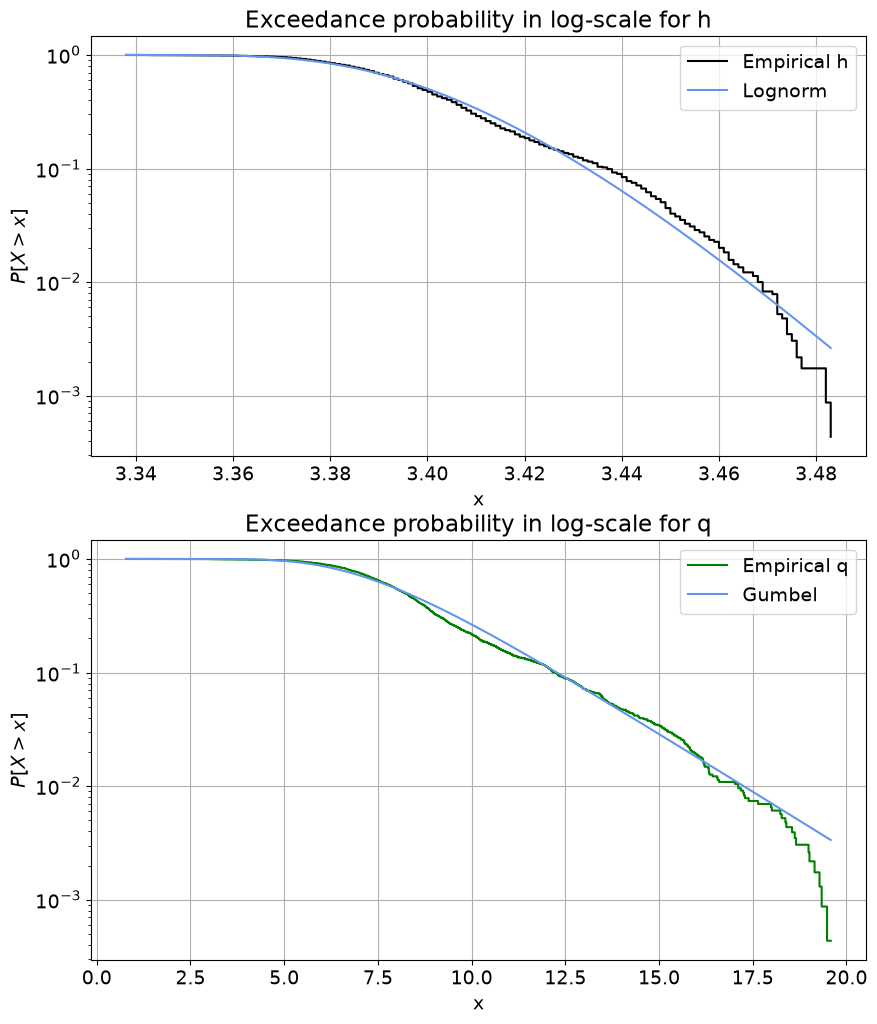

In [123]:
non_ex_prob_h, sort_val_h = ecdf(h)
non_ex_prob_q, sort_val_q = ecdf(q)
cdf_h = stats.lognorm.cdf(sort_val_h, s=params_h[0], loc=params_h[1], scale=params_h[2])
cdf_q = stats.gumbel_r.cdf(sort_val_q, loc=params_q[0], scale=params_q[1])

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
axes[0].step(sort_val_h, 1 - non_ex_prob_h, color='k', label='Empirical h')
axes[1].step(sort_val_q, 1 - non_ex_prob_q, color='g', label='Empirical q')

axes[0].set_xlabel("x"); axes[0].set_ylabel('$P[X > x]$')
axes[0].plot(sort_val_h, 1 - cdf_h, color='cornflowerblue', label='Lognorm')
axes[0].set_title('Exceedance probability in log-scale for h'); axes[0].set_yscale('log')
axes[0].legend(); axes[0].grid()

axes[1].set_xlabel("x"); axes[1].set_ylabel('$P[X > x]$')
axes[1].plot(sort_val_q, 1 - cdf_q, color='cornflowerblue', label='Gumbel')
axes[1].set_title('Exceedance probability in log-scale for q'); axes[1].set_yscale('log')
axes[1].legend(); axes[1].grid()

## Part 5. Propagating the uncertainty

Using the fitted distributions, propagate the uncertainty from $h$ and $q$ to flow velocity $u$, **assuming that $h$ and $q$ are independent**. You will examine that assumption in Section 6.

Recall

$$u=\frac{q}{95h}.$$


>**Task 5 — Monte Carlo propagation:**
>
>
>1. Draw 10,000 independent random samples from the fitted distributions for $h$ and $q$.
>2. Compute the corresponding simulated velocities $u_{sim}=q_{sim}/(95h_{sim})$.
>3. Compute the observed velocities $u_{obs}=q/(95h)$ from the paired measurements.
>4. Compare the observed and simulated velocity distributions using density-normalized histograms and exceedance plots.
>5. Report the mean and standard deviation of both velocity distributions.
>
>Use variable names `rs_h`, `rs_q`, `rs_u`, and `u` so they can be reused below.
>


from random u: mean= 0.0272, std = 0.0085
from u: mean= 0.0267, std = 0.0078


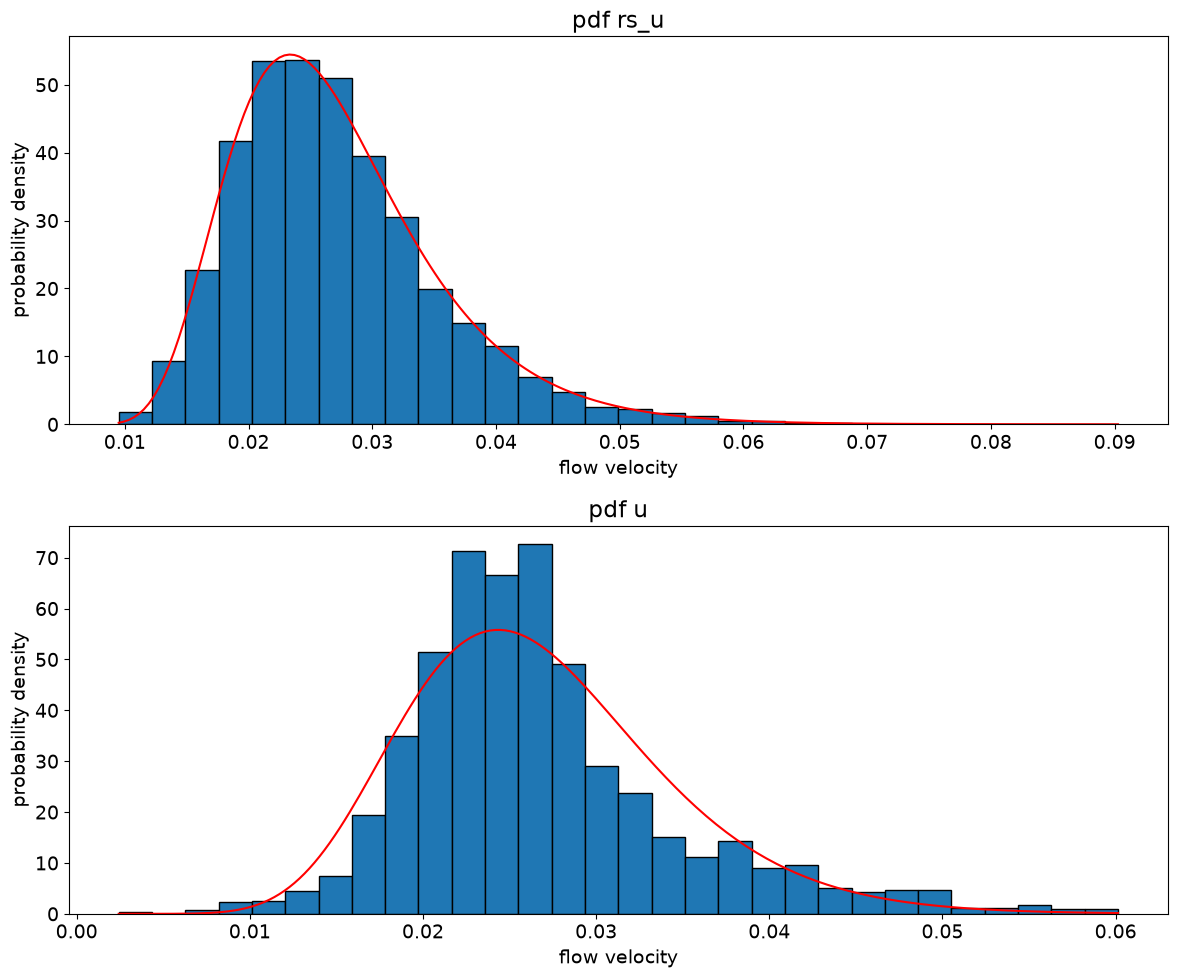

In [139]:
N = 10000
rs_h = stats.lognorm.rvs(s=params_h[0], loc=params_h[1], scale=params_h[2], size=N)
rs_q = stats.gumbel_r.rvs(loc=params_q[0], scale=params_q[1], size=N)

rs_u = rs_q / (95 * rs_h)
u = q / (95 * h)

plt.figure(figsize=(12,10))
plt.subplot(211)
plt.hist(rs_u, bins=30, density=True, edgecolor='black')
x_grid_rsu = np.linspace(rs_u.min(), rs_u.max(), 200)
fit_params_rsu = stats.lognorm.fit(rs_u)
pdf_fitted_rsu = stats.lognorm.pdf(x_grid_rsu, *fit_params_rsu)
plt.plot(x_grid_rsu, pdf_fitted_rsu, 'r-', label='Fitted Lognormal PDF')
plt.title(f"pdf rs_u")
plt.xlabel("flow velocity"), plt.ylabel('probability density')

plt.subplot(212)
plt.hist(u, bins=30, density=True, edgecolor='black')
x_grid_u = np.linspace(u.min(), u.max(), 200)
fit_params_u = stats.lognorm.fit(u)
pdf_fitted_u = stats.lognorm.pdf(x_grid_u, *fit_params_u)
plt.plot(x_grid_u, pdf_fitted_u, 'r-', label='Fitted Lognormal PDF')
plt.title(f'pdf u')
plt.xlabel("flow velocity"), plt.ylabel('probability density')
plt.tight_layout()

print(f"from random u: mean= {rs_u.mean():.4f}, std = {rs_u.std():.4f}")
print(f"from u: mean= {u.mean():.4f}, std = {u.std():.4f}")

## Part 6. Scatter plot and correlation


>**Task 6 — compare dependence:**
>
>
>Make a scatter plot of $h$ against $q$ for:
>
>- the paired **observations** $(h_i,q_i)$; and
>- the independently generated **simulations** $(h_{sim},q_{sim})$.
>
>Compute the Pearson correlation coefficient for each set and store the results as `rho_obs` and `rho_sim`.
>
>Copy both correlation coefficients into your handwritten reference notes. 
>


rho_obs = 0.7535
rho_sim = 0.0097


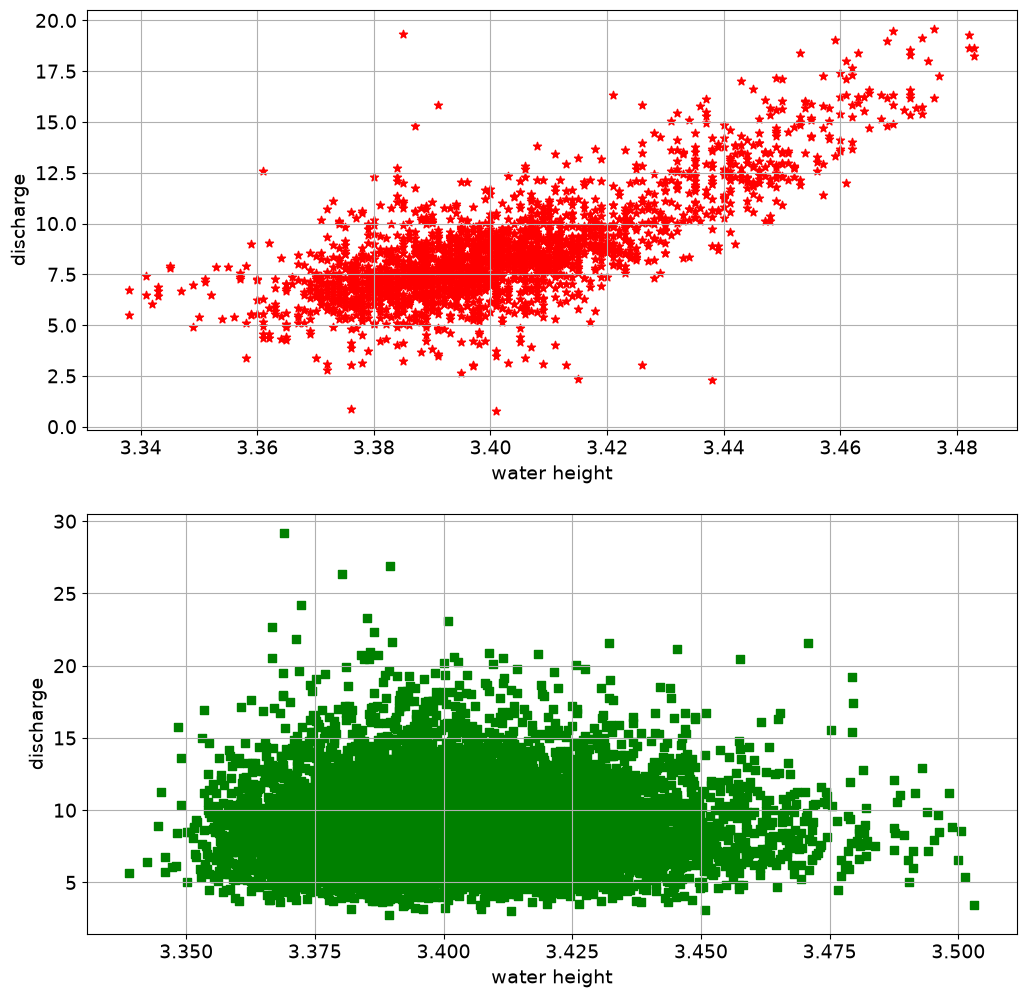

In [125]:
plt.figure(figsize=(12,12))
plt.subplot(211)
plt.scatter(h, q, color='red', marker='*')
plt.grid(); plt.xlabel("water height"); plt.ylabel("discharge")

plt.subplot(212)
plt.scatter(rs_h, rs_q, color='green', marker='s')
plt.grid(); plt.xlabel("water height"); plt.ylabel("discharge")

rho_obs = np.corrcoef(h, q)[0, 1]
rho_sim = np.corrcoef(rs_h, rs_q)[0, 1]

print(f"rho_obs = {rho_obs:.4f}")
print(f"rho_sim = {rho_sim:.4f}")

## Part 7. Contingency tables: prepare two raw tables

This section uses a different dataset: this year's course questionnaire (`dataset_class_survey_contingency.csv`). Very rare response categories were removed or grouped before release.

For the setup phase, your job is only to construct and copy **raw count tables**. 


In [126]:
findfile('dataset_class_survey_contingency.csv')
survey = pd.read_csv('dataset_class_survey_contingency.csv')
survey.head()


,programme,gender,world_region,cats_or_dogs,rock_paper_scissors_round_1,rock_paper_scissors_round_2,rock_paper_scissors_round_3,vacation_style,modelling_uncertainty_or_data,shares_apartment
0,Civil Engineering,Female,Europe,Cats,Paper,Scissors,Rock,Sport holiday,*Incoherent Screaming*,I live alone
1,"Earth, Climate, and Technology",Male,Europe,Dogs,Rock,Paper,Rock,Mountain hike,*Incoherent Screaming*,I live with others
2,"Earth, Climate, and Technology",Female,Europe,Both?,Scissors,Rock,Paper,Nature park,*Incoherent Screaming*,I live with others
3,Civil Engineering,Male,Europe,Dogs,Scissors,Scissors,Scissors,City trip,Modelling,I live with others
4,Civil Engineering,Male,Europe,Dogs,Rock,Rock,Rock,Beach holiday,Modelling,I live with others


>**Task 7.1 — worked example:**
>
>
>The cell below shows the mechanics of constructing a contingency table. Read it and make sure everyone in the group understands what the rows, columns, cells, and totals represent.
>
>Do **not** use this worked example as one of your own two tables below.
>


In [127]:
# WORKED EXAMPLE -- illustrates the mechanic only
example_counts = pd.crosstab(
    survey['programme'],
    survey['cats_or_dogs'],
    margins=True)
example_counts


cats_or_dogs,Both?,Cats,Dogs,Neither! >:(,All
programme,,,,,
Civil Engineering,16,23,30,7,76
"Earth, Climate, and Technology",4,9,6,2,21
Environmental Engineering,9,4,3,1,17
All,29,36,39,10,114


>**Task 7.2 — choose and prepare two tables:**
>
>
>Choose **two different pairs of categorical variables** from the questionnaire that you find worth comparing. Construct a raw contingency table for each pair, including row and column totals.
>
>Make sure the two tables use different variable pairs. Copy **both complete raw count tables**, including labels and totals, accurately into your handwritten reference notes. You will decide how to use one of these tables only after the written questions are handed out.



In [128]:
table1 = pd.crosstab(survey["programme"], survey['vacation_style'], margins=True)
table2 = pd.crosstab(survey["gender"], survey["shares_apartment"], margins=True)

display(table1)

display(table2)


vacation_style,Antarctica cruise,Beach holiday,City trip,Mountain hike,Nature park,Road trip,Sport holiday,All
programme,,,,,,,,
Civil Engineering,4,17,12,12,7,19,5,76
"Earth, Climate, and Technology",1,3,5,5,3,4,0,21
Environmental Engineering,2,2,3,2,5,2,1,17
All,7,22,20,19,15,25,6,114


shares_apartment,I live alone,I live with others,All
gender,,,
Female,9,18,27
Male,18,67,85
All,27,85,112


## Part 8. Prepare your handwritten reference notes — do this before 11:30!

Once laptops close, you may use only the handwritten notes your group prepared during the setup.

The numerical cell below collects the values you will need. Your goodness-of-fit judgements and contingency tables must come from your own work above.


In [129]:
print('='*50)
print('HANDWRITTEN REFERENCE NOTES -- COPY THESE RESULTS BEFORE 11:30')
print('='*50)
print()

print('--- Distribution fitting results ---')
print('q empirical moments: mean=%.3f, std=%.3f, skewness=%.3f' % (np.mean(q), np.std(q, ddof=1), stats.describe(q).skewness))
print('q MLE fitted parameters: '+"%.3f "*len(params_q) % params_q)
print('h empirical moments: mean=%.3f, std=%.3f, skewness=%.3f' % (np.mean(h), np.std(h, ddof=1), stats.describe(h).skewness))
print('h MLE fitted parameters: '+"%.3f "*len(params_h) % params_h)
print()

print('--- Dependence results ---')
print('rho_obs = %.3f' % rho_obs)
print('rho_sim = %.3f' % rho_sim)
print()

print('Also copy by hand:')
print('  1. Your short GOF judgement + supporting graphical evidence (qualitatively) for h')
print('  2. Your short GOF judgement + supporting graphical evidence (qualitatively) for q')
print('  3. A brief justification of your distribution choices for h and q')
print('  4. BOTH complete raw contingency tables from Section 7')

HANDWRITTEN REFERENCE NOTES -- COPY THESE RESULTS BEFORE 11:30

--- Distribution fitting results ---
q empirical moments: mean=8.657, std=2.592, skewness=1.145
q MLE fitted parameters: 7.499 2.121 
h empirical moments: mean=3.402, std=0.023, skewness=0.692
h MLE fitted parameters: 0.192 3.284 0.117 

--- Dependence results ---
rho_obs = 0.753
rho_sim = 0.010

Also copy by hand:
  1. Your short GOF judgement + supporting graphical evidence (qualitatively) for h
  2. Your short GOF judgement + supporting graphical evidence (qualitatively) for q
  3. A brief justification of your distribution choices for h and q
  4. BOTH complete raw contingency tables from Section 7


> By Max Ramgraber, Patricia Mares Nasarre and Robert Lanzafame, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).